# Member 1: Data Architect & KPI Strategist

Notebook nay tao nen tang du lieu sach va nhat quan ve mat tai chinh/ngu nghia cho cac module downstream.

Pham vi:
- `data/01_raw/transaction_data.csv`
- `data/01_raw/product.csv`
- `data/01_raw/hh_demographic.csv`

Deliverables:
- `data/02_processed/master_transactions.parquet`
- `data/02_processed/master_transactions_all.parquet`
- `data/02_processed/master_transactions_organic_only.parquet`

Ghi chu quan trong:
- `SALES_VALUE` duoc dung nhu retailer revenue, khong phai so tien khach tra.
- `Price_Paid_Customer` = `SALES_VALUE + COUPON_DISC` vi `COUPON_DISC` luon am khi co manufacturer coupon.
- Muc roll-up chinh la `COMMODITY_DESC`.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

pd.set_option("display.max_columns", 200)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

RAW_DIR = Path("../data/01_raw")
OUT_DIR = Path("../data/02_processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

TX_PATH = RAW_DIR / "transaction_data.csv"
PRODUCT_PATH = RAW_DIR / "product.csv"
DEMO_PATH = RAW_DIR / "hh_demographic.csv"

## Step 1.1: Resolve the `SALES_VALUE` trap

Muc tieu:
- Tao 3 cot nen tang: `Revenue_Retailer`, `Price_Paid_Customer`, `Is_Promoted_Item`.
- Xac thuc thu cong 10 dong theo logic trong User Guide page 3.

Quyet dinh lam sach:
- Loai bo cac dong `QUANTITY <= 0` khoi bang chuan vi khong the tinh metric per-unit mot cach co nghia.

In [2]:
tx_dtypes = {
    "household_key": "int32",
    "BASKET_ID": "int64",
    "DAY": "int32",
    "PRODUCT_ID": "int32",
    "QUANTITY": "int32",
    "SALES_VALUE": "float32",
    "STORE_ID": "int32",
    "RETAIL_DISC": "float32",
    "TRANS_TIME": "int32",
    "WEEK_NO": "int16",
    "COUPON_DISC": "float32",
    "COUPON_MATCH_DISC": "float32",
}

tx = pd.read_csv(TX_PATH, dtype=tx_dtypes)
product = pd.read_csv(PRODUCT_PATH)
demographic = pd.read_csv(DEMO_PATH)

quality_snapshot = pd.DataFrame(
    {
        "metric": [
            "raw_transaction_rows",
            "raw_unique_baskets",
            "raw_unique_products",
            "raw_unique_commodities",
            "rows_with_quantity_le_zero",
        ],
        "value": [
            len(tx),
            tx["BASKET_ID"].nunique(),
            tx["PRODUCT_ID"].nunique(),
            product["COMMODITY_DESC"].nunique(),
            (tx["QUANTITY"] <= 0).sum(),
        ],
    }
)
quality_snapshot

,metric,value
0,raw_transaction_rows,2595732
1,raw_unique_baskets,276484
2,raw_unique_products,92339
3,raw_unique_commodities,308
4,rows_with_quantity_le_zero,14466


In [3]:
tx = tx.loc[tx["QUANTITY"] > 0].copy()

tx["Revenue_Retailer_Total"] = tx["SALES_VALUE"]
tx["Revenue_Retailer"] = tx["Revenue_Retailer_Total"] / tx["QUANTITY"]
tx["Price_Paid_Customer_Total"] = tx["SALES_VALUE"] + tx["COUPON_DISC"]
tx["Price_Paid_Customer"] = tx["Price_Paid_Customer_Total"] / tx["QUANTITY"]
tx["Is_Promoted_Item"] = (
    tx[["RETAIL_DISC", "COUPON_DISC", "COUPON_MATCH_DISC"]] != 0
).any(axis=1)
tx["Guide_Shelf_Price_Per_Unit"] = (
    tx["SALES_VALUE"] - tx["RETAIL_DISC"] - tx["COUPON_MATCH_DISC"]
) / tx["QUANTITY"]

validation_sample = pd.concat(
    [
        tx.query("RETAIL_DISC == 0 and COUPON_DISC == 0 and COUPON_MATCH_DISC == 0").head(4),
        tx.query("RETAIL_DISC != 0 and COUPON_DISC == 0").head(3),
        tx.query("COUPON_DISC != 0").head(3),
    ],
    ignore_index=True,
).drop_duplicates().head(10)

validation_view = validation_sample[
    [
        "household_key",
        "BASKET_ID",
        "PRODUCT_ID",
        "QUANTITY",
        "SALES_VALUE",
        "RETAIL_DISC",
        "COUPON_DISC",
        "COUPON_MATCH_DISC",
        "Revenue_Retailer",
        "Price_Paid_Customer",
        "Guide_Shelf_Price_Per_Unit",
        "Is_Promoted_Item",
    ]
].copy()

validation_view

,household_key,BASKET_ID,PRODUCT_ID,QUANTITY,SALES_VALUE,RETAIL_DISC,COUPON_DISC,COUPON_MATCH_DISC,Revenue_Retailer,Price_Paid_Customer,Guide_Shelf_Price_Per_Unit,Is_Promoted_Item
0,2375,26984851472,1033142,1,0.8200,0.0000,0.0000,0.0000,0.8200,0.8200,0.8200,False
1,2375,26984851472,1082185,1,1.2100,0.0000,0.0000,0.0000,1.2100,1.2100,1.2100,False
2,2375,26984851516,1102651,1,1.8900,0.0000,0.0000,0.0000,1.8900,1.8900,1.8900,False
3,1364,26984896261,842930,1,2.1900,0.0000,0.0000,0.0000,2.1900,2.1900,2.1900,False
4,2375,26984851472,1004906,1,1.3900,-0.6000,0.0000,0.0000,1.3900,1.3900,1.9900,True
5,2375,26984851472,1036325,1,0.9900,-0.3000,0.0000,0.0000,0.9900,0.9900,1.2900,True
6,2375,26984851472,8160430,1,1.5000,-0.3900,0.0000,0.0000,1.5000,1.5000,1.8900,True
7,718,26985360571,830503,1,2.9900,-1.0000,-1.0000,0.0000,2.9900,1.9900,3.9900,True
8,718,26985360571,855325,1,1.1000,-0.6900,-0.4000,-0.4000,1.1000,0.7000,2.1900,True
9,718,26985360571,934676,1,1.3700,-0.4200,-1.0000,0.0000,1.3700,0.3700,1.7900,True


## Step 1.2-1.4: Roll-up to `COMMODITY_DESC`, build Organic Basket, and compute baseline KPI

Thiet ke bang master:
- Grain: `household_key x BASKET_ID x DAY x WEEK_NO x STORE_ID x COMMODITY_DESC`
- Muc dich: giam sparsity SKU-level, giu lai logic need-state cho recommender va MBA.
- Demographic duoc join truc tiep theo `household_key` de downstream co the dung ngay.

In [4]:
tx_enriched = tx.merge(product, on="PRODUCT_ID", how="left", validate="many_to_one")
tx_enriched = tx_enriched.merge(demographic, on="household_key", how="left", validate="many_to_one")

tx_enriched["COMMODITY_DESC"] = tx_enriched["COMMODITY_DESC"].fillna("UNKNOWN_COMMODITY")
tx_enriched["SUB_COMMODITY_DESC"] = tx_enriched["SUB_COMMODITY_DESC"].fillna("UNKNOWN_SUB_COMMODITY")
tx_enriched["DEPARTMENT"] = tx_enriched["DEPARTMENT"].fillna("UNKNOWN_DEPARTMENT")
tx_enriched["BRAND"] = tx_enriched["BRAND"].fillna("UNKNOWN_BRAND")

basket_promo_flag = tx_enriched.groupby("BASKET_ID")["Is_Promoted_Item"].transform("any")
tx_enriched["Basket_Is_Organic"] = ~basket_promo_flag

group_cols = [
    "household_key",
    "BASKET_ID",
    "DAY",
    "WEEK_NO",
    "STORE_ID",
    "TRANS_TIME",
    "COMMODITY_DESC",
    "classification_1",
    "classification_2",
    "classification_3",
    "classification_4",
    "classification_5",
    "HOMEOWNER_DESC",
    "KID_CATEGORY_DESC",
]

master_transactions_all = (
    tx_enriched.groupby(group_cols, dropna=False)
    .agg(
        Total_Quantity=("QUANTITY", "sum"),
        Revenue_Retailer_Total=("Revenue_Retailer_Total", "sum"),
        Price_Paid_Customer_Total=("Price_Paid_Customer_Total", "sum"),
        Retail_Discount_Total=("RETAIL_DISC", "sum"),
        Coupon_Discount_Total=("COUPON_DISC", "sum"),
        Coupon_Match_Discount_Total=("COUPON_MATCH_DISC", "sum"),
        Distinct_SKU_Count=("PRODUCT_ID", "nunique"),
        Distinct_Subcommodity_Count=("SUB_COMMODITY_DESC", "nunique"),
        Is_Promoted_Item=("Is_Promoted_Item", "max"),
        Basket_Is_Organic=("Basket_Is_Organic", "max"),
    )
    .reset_index()
)

master_transactions_all["Revenue_Retailer"] = (
    master_transactions_all["Revenue_Retailer_Total"]
    / master_transactions_all["Total_Quantity"]
)
master_transactions_all["Price_Paid_Customer"] = (
    master_transactions_all["Price_Paid_Customer_Total"]
    / master_transactions_all["Total_Quantity"]
)

master_transactions_organic_only = master_transactions_all.loc[
    master_transactions_all["Basket_Is_Organic"]
].copy()

median_basket_diversity = float(
    master_transactions_all.groupby("BASKET_ID")["COMMODITY_DESC"].nunique().median()
)

summary_metrics = pd.DataFrame(
    {
        "metric": [
            "master_rows_all",
            "master_rows_organic_only",
            "unique_baskets_all",
            "unique_baskets_organic_only",
            "share_organic_baskets",
            "median_basket_diversity",
        ],
        "value": [
            len(master_transactions_all),
            len(master_transactions_organic_only),
            master_transactions_all["BASKET_ID"].nunique(),
            master_transactions_organic_only["BASKET_ID"].nunique(),
            master_transactions_organic_only["BASKET_ID"].nunique()
            / master_transactions_all["BASKET_ID"].nunique(),
            median_basket_diversity,
        ],
    }
)

summary_metrics

,metric,value
0,master_rows_all,"1,904,671.0000"
1,master_rows_organic_only,"80,665.0000"
2,unique_baskets_all,"275,889.0000"
3,unique_baskets_organic_only,"45,027.0000"
4,share_organic_baskets,0.1632
5,median_basket_diversity,4.0000


In [5]:
master_path = OUT_DIR / "master_transactions.parquet"
master_all_path = OUT_DIR / "master_transactions_all.parquet"
master_organic_path = OUT_DIR / "master_transactions_organic_only.parquet"

def save_parquet_with_fallback(df: pd.DataFrame, path: Path) -> str:
    last_error = None
    for engine in ("pyarrow", "fastparquet"):
        try:
            df.to_parquet(path, index=False, engine=engine)
            return engine
        except Exception as err:
            last_error = err
    raise RuntimeError(
        f"Could not save {path.name} with pyarrow or fastparquet. Last error: {last_error}"
    )

engine_used = save_parquet_with_fallback(master_transactions_all, master_path)
save_parquet_with_fallback(master_transactions_all, master_all_path)
save_parquet_with_fallback(master_transactions_organic_only, master_organic_path)

print(f"Saved: {master_path}")
print(f"Saved: {master_all_path}")
print(f"Saved: {master_organic_path}")
print(f"Parquet engine used: {engine_used}")
print(f"Median Basket Diversity = {median_basket_diversity:.2f}")

Saved: ..\data\02_processed\master_transactions.parquet
Saved: ..\data\02_processed\master_transactions_all.parquet
Saved: ..\data\02_processed\master_transactions_organic_only.parquet
Parquet engine used: pyarrow
Median Basket Diversity = 4.00


## Step 1.5: Module 1 QA Gate and Strategy Notes

Muc tieu cua QA gate nay la chot 3 dieu truoc khi hand-off sang Module 2-4:

- **Data integrity:** cot nen tang va parquet outputs ton tai day du.
- **Financial semantics:** logic `Revenue_Retailer` va `Price_Paid_Customer` nhat quan voi dinh nghia business.
- **Behavioral validity:** Organic Basket thuc su khong chua item promoted.

Vi sao can buoc nay:

- Neu sai sematics tai Day 1, tat ca uplift/margin/context sau do se bi lech.
- Kiem tra co he thong giup tranh loi ngat quang khi doi environment (engine parquet, path, package).
- Cac metric baseline duoi day tao 'evidence trail' de bao cao hoc thuat va dashboard.

,check,status
0,has_required_tx_columns,PASS
1,master_has_required_outputs,PASS
2,organic_baskets_have_no_promoted_items,PASS
3,parquet_outputs_exist,PASS
4,median_diversity_recomputed_matches,PASS


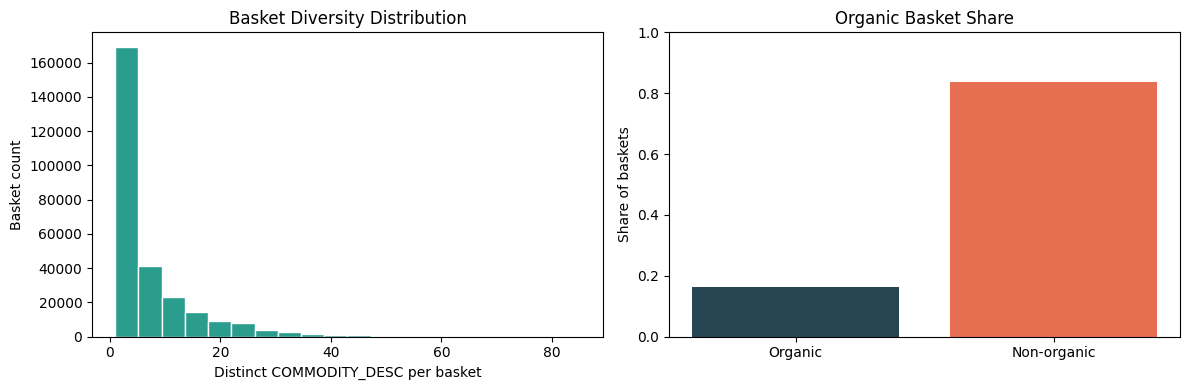

,metric,value
0,master_rows_all,"1,904,671.0000"
1,master_rows_organic_only,"80,665.0000"
2,unique_baskets_all,"275,889.0000"
3,unique_baskets_organic_only,"45,027.0000"
4,share_organic_baskets,0.1632
5,median_basket_diversity,4.0000


In [6]:
from pathlib import Path

qa_checks = {
    "has_required_tx_columns": all(
        c in tx.columns
        for c in [
            "Revenue_Retailer",
            "Price_Paid_Customer",
            "Is_Promoted_Item",
            "Revenue_Retailer_Total",
            "Price_Paid_Customer_Total",
        ]
    ),
    "master_has_required_outputs": all(
        c in master_transactions_all.columns
        for c in [
            "COMMODITY_DESC",
            "Basket_Is_Organic",
            "Revenue_Retailer_Total",
            "Price_Paid_Customer_Total",
        ]
    ),
    "organic_baskets_have_no_promoted_items": bool(
        (
            tx_enriched.groupby("BASKET_ID")["Is_Promoted_Item"]
            .max()
            .loc[master_transactions_organic_only["BASKET_ID"].unique()]
            == 0
        ).all()
    ),
    "parquet_outputs_exist": all(
        p.exists() for p in [master_path, master_all_path, master_organic_path]
    ),
    "median_diversity_recomputed_matches": float(
        master_transactions_all.groupby("BASKET_ID")["COMMODITY_DESC"].nunique().median()
    )
    == float(median_basket_diversity),
}

module1_qa = pd.DataFrame(
    {
        "check": list(qa_checks.keys()),
        "status": ["PASS" if v else "FAIL" for v in qa_checks.values()],
    }
)
display(module1_qa)

kpi_view = summary_metrics.copy()
kpi_view["value"] = pd.to_numeric(kpi_view["value"], errors="coerce")

try:
    import matplotlib.pyplot as plt

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    basket_div = master_transactions_all.groupby("BASKET_ID")["COMMODITY_DESC"].nunique()
    axes[0].hist(basket_div, bins=20, color="#2a9d8f", edgecolor="white")
    axes[0].set_title("Basket Diversity Distribution")
    axes[0].set_xlabel("Distinct COMMODITY_DESC per basket")
    axes[0].set_ylabel("Basket count")

    organic_share = float(
        master_transactions_organic_only["BASKET_ID"].nunique()
        / master_transactions_all["BASKET_ID"].nunique()
    )
    non_organic_share = 1.0 - organic_share
    axes[1].bar(
        ["Organic", "Non-organic"],
        [organic_share, non_organic_share],
        color=["#264653", "#e76f51"],
    )
    axes[1].set_ylim(0, 1)
    axes[1].set_title("Organic Basket Share")
    axes[1].set_ylabel("Share of baskets")

    plt.tight_layout()
    plt.show()
except Exception as viz_err:
    print(f"Visualization skipped: {viz_err}")

summary_metrics